# AR VTO StatsModel 

In [1]:
from datetime import datetime

# Get the current date and time
current_time = datetime.now()

print(f"Current date and time: {current_time}")

Current date and time: 2024-11-18 16:18:37.837370


### Change Log

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import json

In [3]:
#read csv file

df_survey_cleaned = pd.read_csv('df_survey_cleaned.csv')

In [4]:
df_survey_cleaned.head()

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,...,HMPU_centered_squared,HMPU_centered_cubed,HMPEOU_centered_squared,HMPEOU_centered_cubed,HMSOI_centered_squared,HMSOI_centered_cubed,HMSEI_centered_squared,HMSEI_centered_cubed,HMPE_centered_squared,HMPE_centered_cubed
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,...,0.005502,-0.000408,0.001576,0.000063,0.008683,-0.000809,0.008909,-0.000841,0.000717,0.000019
1,13/10/2022 13:29:22,3.0,3.0,3.0,Mua sắm,3.0,3.0,3.0,3.0,3.0,...,0.506365,0.360325,0.365972,0.221397,0.385454,0.239309,0.395492,0.248717,0.477600,0.330062
2,13/10/2022 21:37:46,5.0,5.0,5.0,"Học tập, giáo dục",4.0,4.0,4.0,4.0,4.0,...,0.000562,0.000013,0.001576,0.000063,0.001393,0.000052,0.001304,0.000047,0.000717,0.000019
3,14/10/2022 12:31:04,3.0,3.0,3.0,"Giải trí, Mua sắm thời trang",2.0,2.0,2.0,2.0,4.0,...,0.042150,0.008653,0.118302,0.040690,0.001653,0.000067,2.469073,-3.879723,0.635557,0.506677
4,14/10/2022 12:37:35,4.0,1.0,1.0,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",1.0,2.0,4.0,4.0,3.0,...,0.001727,-0.000072,0.001576,0.000063,0.003667,-0.000222,0.008909,-0.000841,0.010759,-0.001116


In [5]:
df_survey_cleaned.shape

(424, 198)

1. STATSModel with Original TAM Features
Formula: BI ~ AT + PU + PEOU + PE + HM + SOI + SEI + PPV + C(AGE_num) + C(Gender_num)
                            OLS Regression Results                            
Dep. Variable:                     BI   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     150.9
Date:                Mon, 18 Nov 2024   Prob (F-statistic):          2.99e-142
Time:                        16:18:40   Log-Likelihood:                -186.03
No. Observations:                 424   AIC:                             398.1
Df Residuals:                     411   BIC:                             450.7
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.9

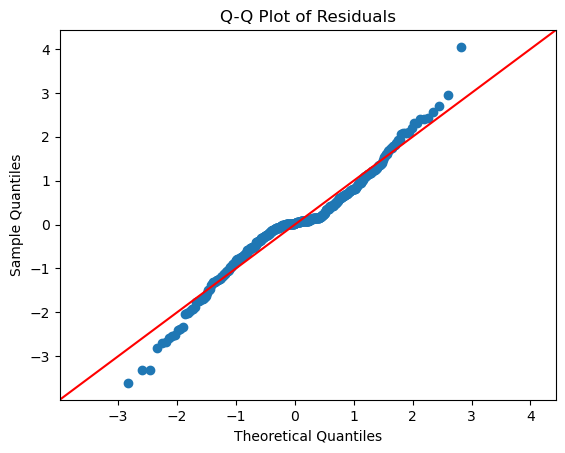

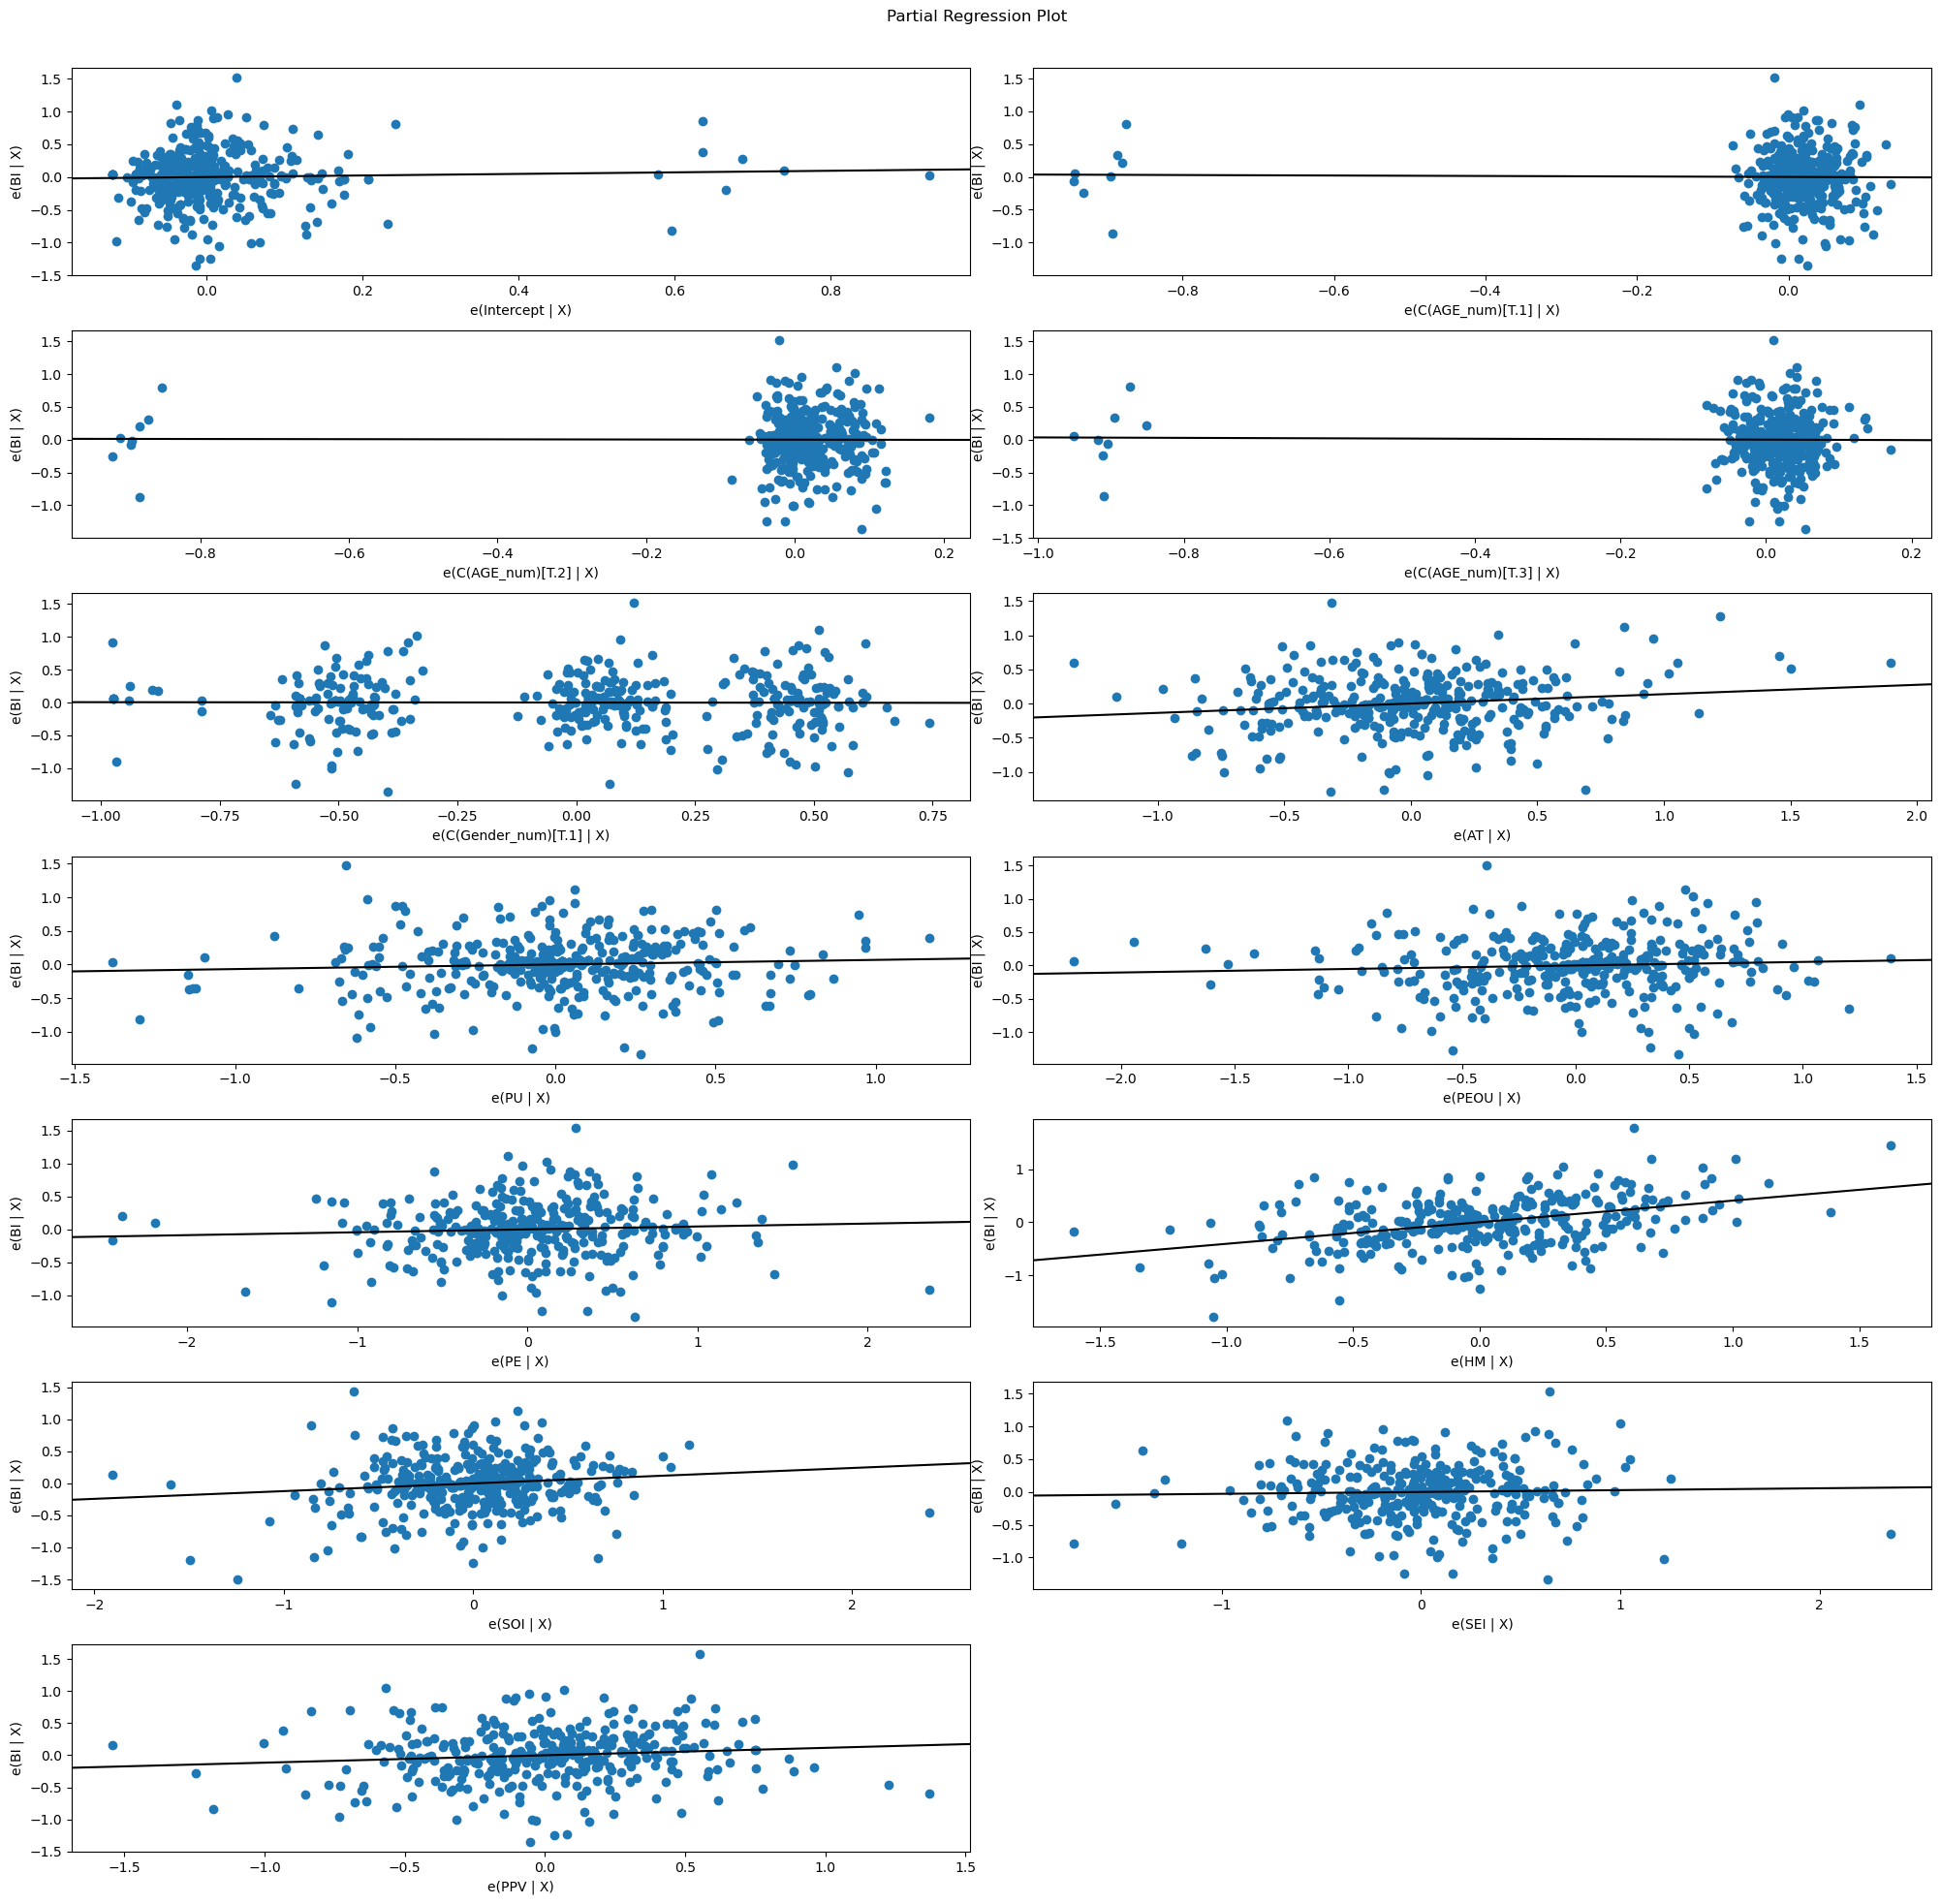

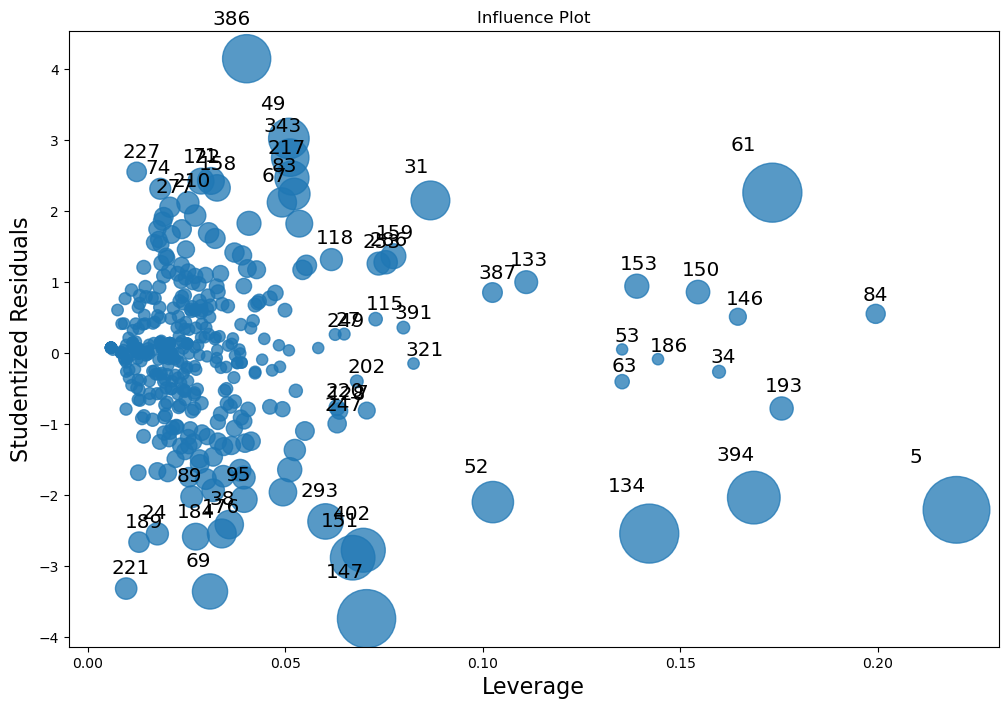

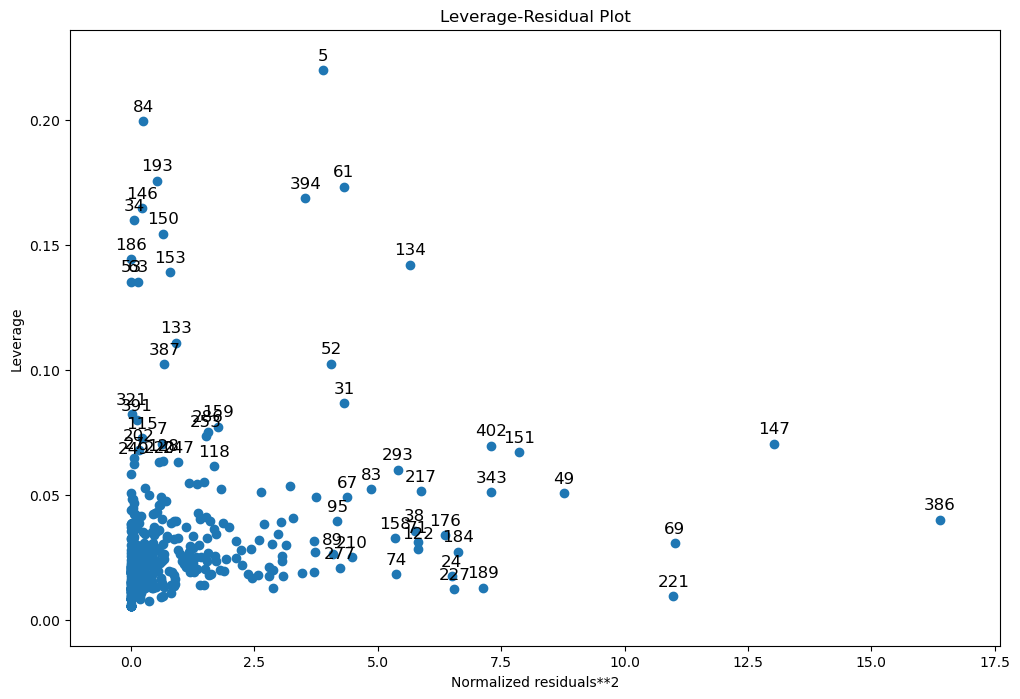

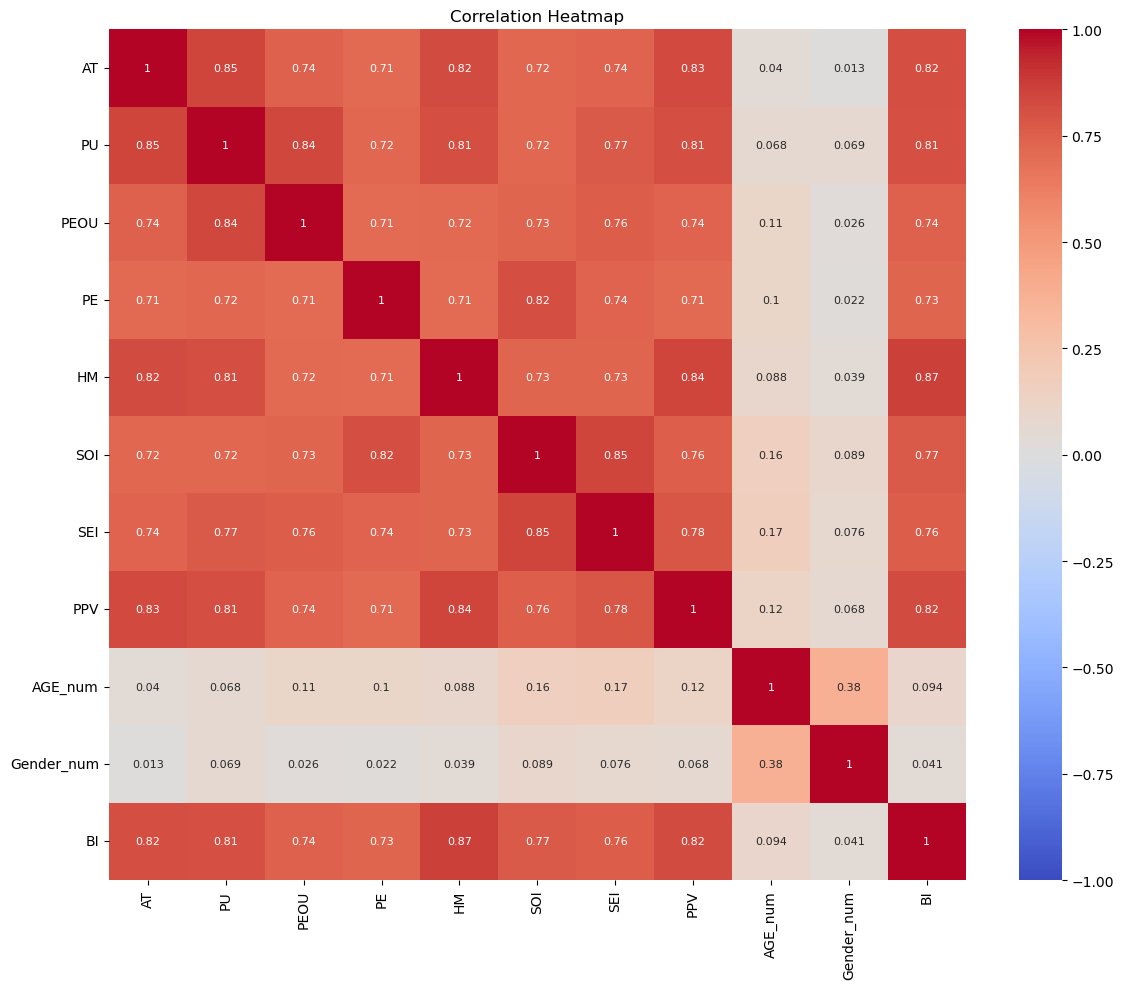

end of  script 1


In [6]:
print('1. STATSModel with Original TAM Features')
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import explained_variance_score
import seaborn as sns
import warnings
 
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels.graphics.regressionplots")

# List of independent variables
feature_vars = ['AT', 'PU', 'PEOU', 'PE', 'HM', 'SOI', 'SEI', 'PPV', 'AGE_num', 'Gender_num']

# Create the formula string
formula = "BI ~ " + " + ".join(feature_vars)

# For categorical variables, we use C() to tell statsmodels to treat them as categorical
formula = formula.replace('AGE_num', 'C(AGE_num)')
formula = formula.replace('Gender_num', 'C(Gender_num)')

# Print the formula to verify
print("Formula:", formula)

# Fit the model
model = smf.ols(formula=formula, data=df_survey_cleaned).fit()

# Print the summary
print(model.summary())

# Calculate additional metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = df_survey_cleaned['BI']
y_pred = model.predict(df_survey_cleaned)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nAdditional Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Calculate metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
evs = explained_variance_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
# Calculate metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
evs = explained_variance_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)


# Create a DataFrame with each metric in its own column

StatsModel_1_metrics_df = pd.DataFrame({
    'model_name': ['STATSModel(TAM )'],
    'run_type': ['Initial Run'],
    'R-squared': [r2],
    'Mean Squared Error (MSE)': [mse],
    'Root Mean Squared Error (RMSE)': [rmse],
    'Explained Variance Score (EVS)': [evs],
    'Mean Absolute Error (MAE)': [mae]
})

# Format all columns to display 4 decimal places
#metrics_df = metrics_df.applymap(lambda x: f"{x:.4f}")

# Display the metrics DataFrame
print(StatsModel_1_metrics_df)
 

import os

# Get the current working directory
current_dir = os.getcwd()

# Create the full file path
file_path = os.path.join(current_dir, 'StatsModel_1_metrics_df.csv')

# Save the DataFrame to CSV in the current directory
StatsModel_1_metrics_df.to_csv(file_path, index=False)

print(f"Metrics saved to: {file_path}")

# 2. Q-Q Plot
fig = sm.qqplot(model.resid, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

# 3. Partial Regression Plots
fig = sm.graphics.plot_partregress_grid(model, fig=plt.figure(figsize=(20, 20)))
plt.show()

# 4. Influence Plot
fig, ax = plt.subplots(figsize=(12, 8))
sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
plt.title("Influence Plot")
plt.show()

# 5. Leverage-Residual Plot
fig, ax = plt.subplots(figsize=(12, 8))
sm.graphics.plot_leverage_resid2(model, ax=ax)
plt.title("Leverage-Residual Plot")
plt.show()


# 7. Correlation Heatmap
# 7. Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_survey_cleaned[feature_vars + ['BI']].corr(), 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            center=0,
            annot_kws={'size': 8})  # Adjust this value to change font size
plt.title("Correlation Heatmap")
plt.tight_layout()  # This ensures the entire plot fits within the figure
plt.show()

print('end of  script 1')

## 2. StatsModel with PCA Features

2. STATSModel with PCA Features
Type of pca_selected_features: <class 'list'>
First few items in pca_selected_features:
  GenderPEOU_centered (type: <class 'str'>)
  AGEGender_centered_squared (type: <class 'str'>)
  GenderPE_centered (type: <class 'str'>)
  AGEPU_centered_squared (type: <class 'str'>)
  AGEAT_centered (type: <class 'str'>)

Successfully loaded 10 unique PCA selected features.

First 5 features:
- GenderPEOU_centered
- AGEGender_centered_squared
- GenderPE_centered
- AGEPU_centered_squared
- AGEAT_centered

Last 5 features:
- AT_centered_squared
- AGE_num_3
- Gender_num_1
- AGE_num_1
- AGE_num_2

Number of unique features: 10
Number of features selected: 64
Selected features:
['GenderPEOU_centered', 'AGEGender_centered_squared', 'GenderPE_centered', 'AGEPU_centered_squared', 'AGEAT_centered', 'AGEPEOU_centered_squared', 'AGEHM_centered', 'AGEPE_centered', 'AGEGender_centered', 'HM_centered', 'GenderPEOU_centered_squared', 'PPV_centered', 'GenderHM_centered', 'SOI_cente

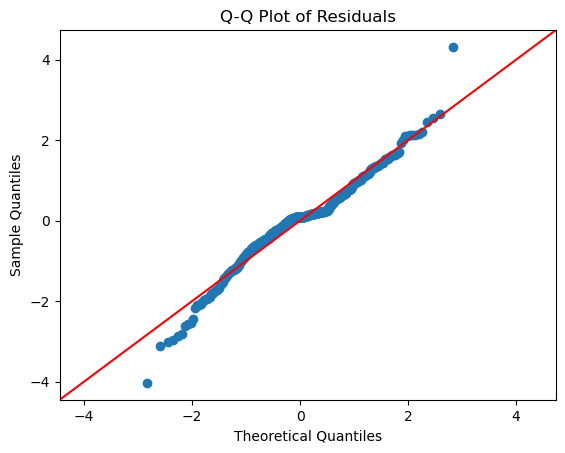

end of  script 2


In [7]:
print('2. STATSModel with PCA Features')

# Open and read the JSON file
try:
    with open('PCA_selected_features.json', 'r') as json_file:
        feature_data = json.load(json_file)

    # Extract the list of selected features
    pca_selected_features = feature_data['PCA_selected_features']

    print("Type of pca_selected_features:", type(pca_selected_features))
    print("First few items in pca_selected_features:")
    for item in pca_selected_features[:5]:
        print(f"  {item} (type: {type(item)})")

    # If pca_selected_features is a list of strings, use this:
    selected_features = list(dict.fromkeys(pca_selected_features))

    print(f"\nSuccessfully loaded {len(feature_vars)} unique PCA selected features.")
    print("\nFirst 5 features:")
    for feature in selected_features[:5]:
        print(f"- {feature}")

    print(f"\nLast 5 features:")
    for feature in selected_features[-5:]:
        print(f"- {feature}")

    print(f"\nNumber of unique features: {len(feature_vars)}")

except FileNotFoundError:
    print("Error: The file 'PCA_selected_features.json' was not found.")
except json.JSONDecodeError:
    print("Error: There was a problem decoding the JSON file.")
except KeyError:
    print("Error: The key 'PCA_selected_features' was not found in the JSON file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
# Select all features from PCA json file
feature_vars = selected_features

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

# AGE and Gender are both numerical categorical features, check to see if AGE_num_1, 2,3 and Gender_num_1 are in the PCA list but not in df_survey_cleaned
missing_columns = [col for col in feature_vars if col not in df_survey_cleaned.columns]
print("Missing columns:", missing_columns)

# First, check if 'AGE' and 'Gender' columns exist
if 'AGE_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            # Binary variable
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            # Categorical variable
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

# Convert boolean columns to int
bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

# Ensure all features are numeric
feature_vars = [col for col in feature_vars if df_survey_cleaned[col].dtype in ['int64', 'float64']]

print("Updated feature variables:", feature_vars)
print(df_survey_cleaned[feature_vars].dtypes)


y = df_survey_cleaned['BI']
X = df_survey_cleaned[feature_vars]

# Add a constant term to the independent variables
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

#print model summary results
print(model.summary())

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, explained_variance_score, mean_absolute_error, r2_score

# Assuming you have already created your model using statsmodels like this:
# model = sm.OLS(y, X).fit()

# Get the predicted values
y_pred = model.predict(X)

# Calculate metrics
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
evs = explained_variance_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

# Create a DataFrame with each metric in its own column

StatsModel_2_metrics_df = pd.DataFrame({
    'model_name': ['STATSModel(PCA)'],
    'run_type': ['2nd Run'],
    'R-squared': [r2],
    'Mean Squared Error (MSE)': [mse],
    'Root Mean Squared Error (RMSE)': [rmse],
    'Explained Variance Score (EVS)': [evs],
    'Mean Absolute Error (MAE)': [mae]
})

# Format all columns to display 4 decimal places
#StatsModel_2_metrics_df = metrics_df.applymap(lambda x: f"{x:.4f}")

# Display the metrics DataFrame
print(StatsModel_2_metrics_df)

# Display the metrics DataFrame
print(StatsModel_2_metrics_df)

import os

# Get the current working directory
current_dir = os.getcwd()

# Create the full file path
file_path = os.path.join(current_dir, 'StatsModel_2_metrics_df.csv')

# Save the DataFrame to CSV in the current directory
StatsModel_2_metrics_df.to_csv(file_path, index=False)

print(f"Metrics saved to: {file_path}")

# 2. Q-Q Plot
fig = sm.qqplot(model.resid, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

print('end of  script 2')

In [8]:
# 3. Partial Regression Plots
#fig = sm.graphics.plot_partregress_grid(model, fig=plt.figure(figsize=40,40))
#plt.show()

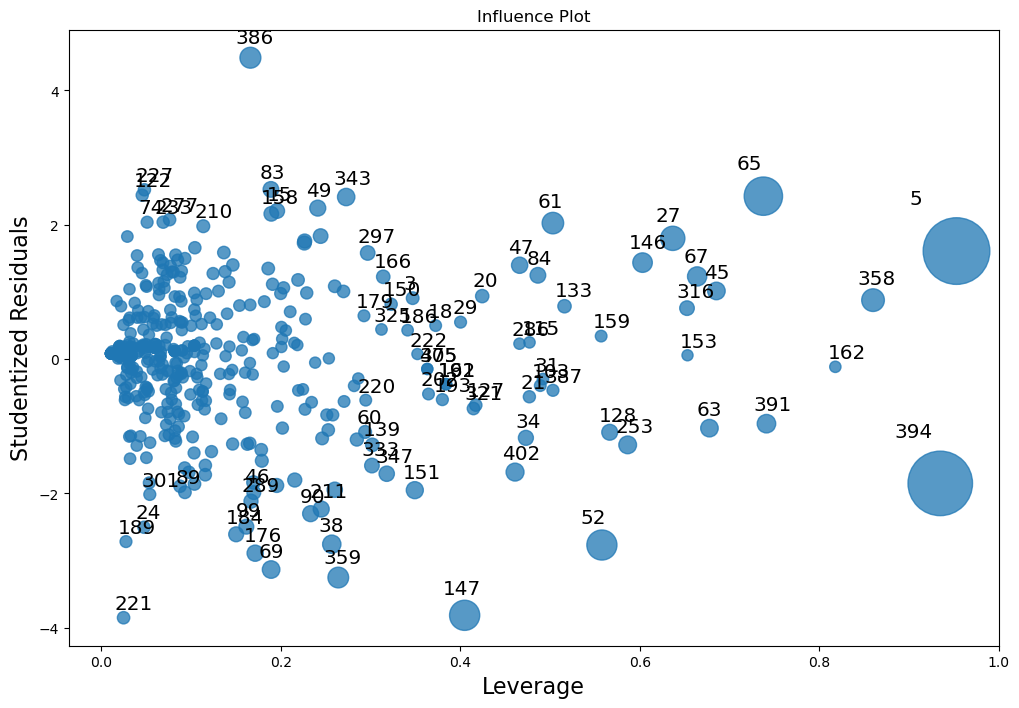

In [9]:
# 4. Influence Plot
fig, ax = plt.subplots(figsize=(12, 8))
sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
plt.title("Influence Plot")
plt.show()



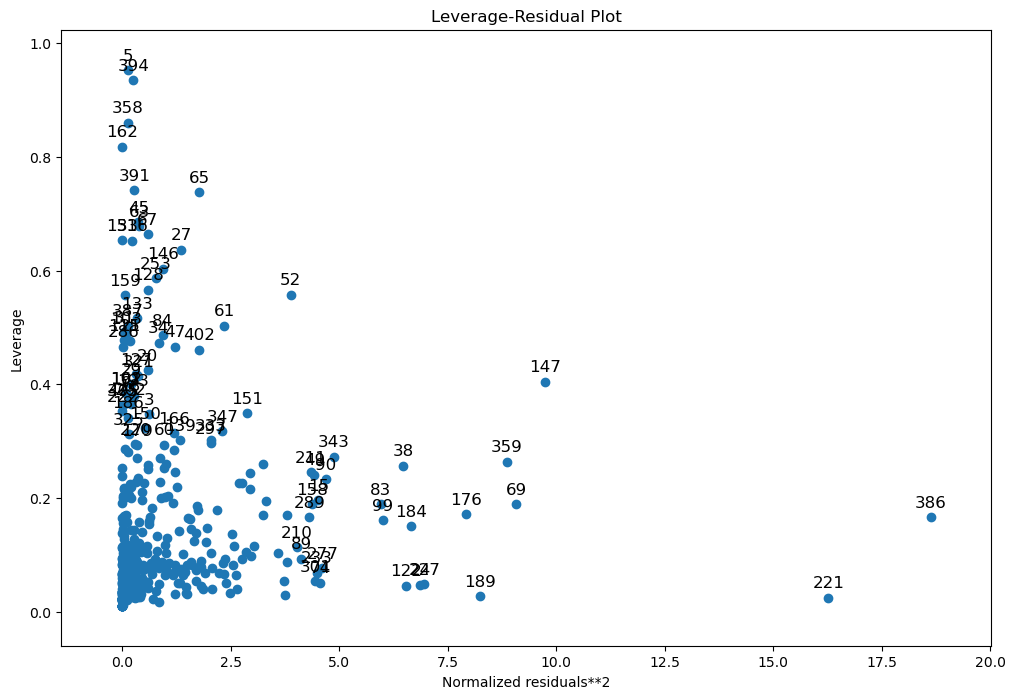

In [10]:
# 5. Leverage-Residual Plot
fig, ax = plt.subplots(figsize=(12, 8))
sm.graphics.plot_leverage_resid2(model, ax=ax)
plt.title("Leverage-Residual Plot")
plt.show()



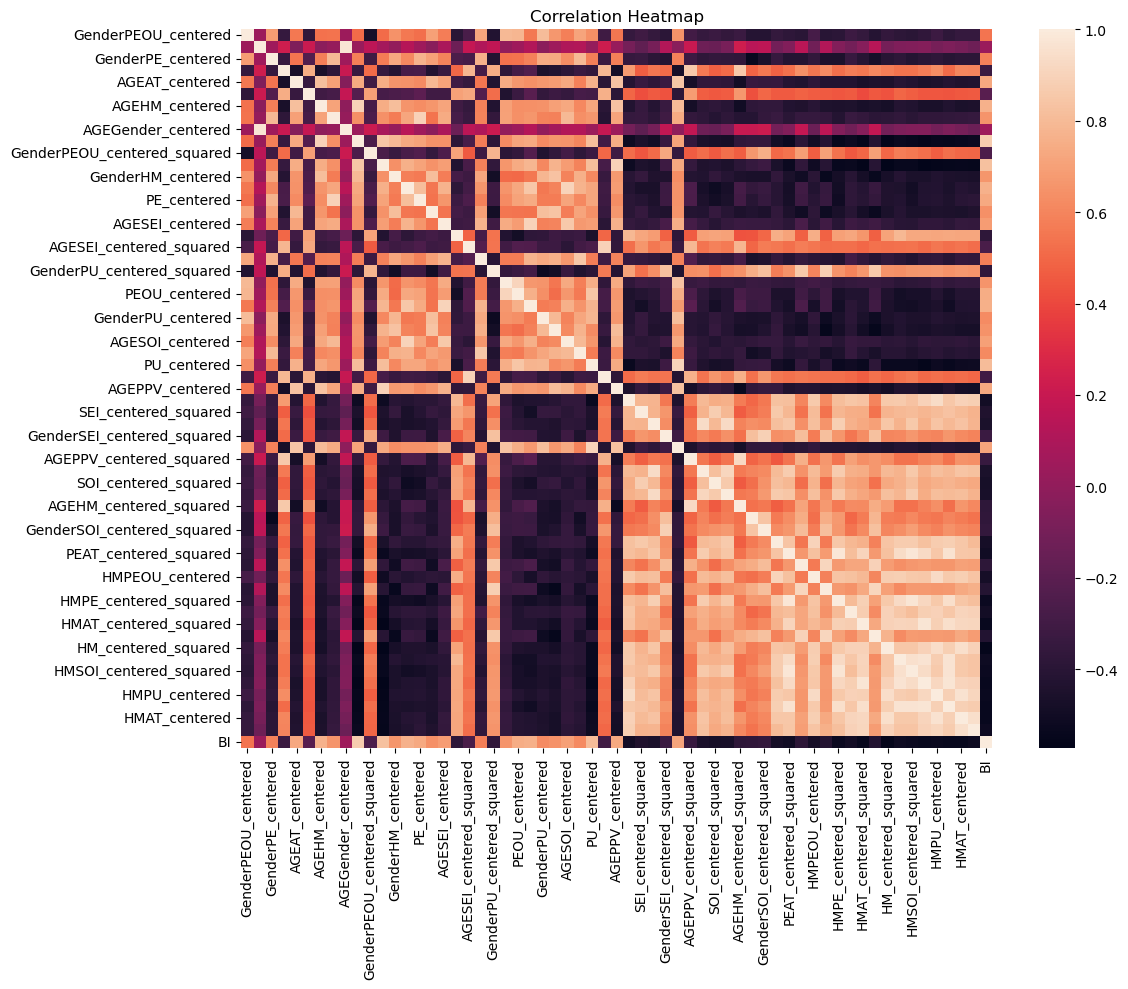

In [11]:
# 7. Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_survey_cleaned[feature_vars + ['BI']].corr())
plt.title("Correlation Heatmap")
plt.tight_layout()  # This ensures the entire plot fits within the figure
plt.show()

### Combine metrics dataset

In [12]:
STATSModel_All_combined_metrics = pd.concat([StatsModel_1_metrics_df,StatsModel_2_metrics_df],axis=0)

In [13]:
STATSModel_All_combined_metrics

,model_name,run_type,R-squared,Mean Squared Error (MSE),Root Mean Squared Error (RMSE),Explained Variance Score (EVS),Mean Absolute Error (MAE)
0,STATSModel(TAM ),Initial Run,0.815007,0.140804,0.375239,0.815007,0.259244
0,STATSModel(PCA),2nd Run,0.854197,0.110975,0.333130,0.854197,0.238904


In [14]:
STATSModel_All_combined_metrics.to_csv('STATSModel_All_combined_metrics.csv')

## 3. STATS Model with most significant features from model.summary generated in step 1

 3. STATS Model with most significant features from model.summary generated in step 2
                            OLS Regression Results                            
Dep. Variable:                     BI   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     197.3
Date:                Mon, 18 Nov 2024   Prob (F-statistic):          1.03e-143
Time:                        16:18:46   Log-Likelihood:                -190.68
No. Observations:                 424   AIC:                             401.4
Df Residuals:                     414   BIC:                             441.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

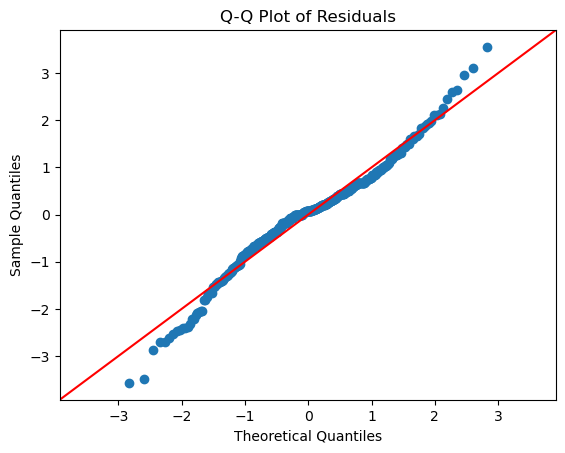

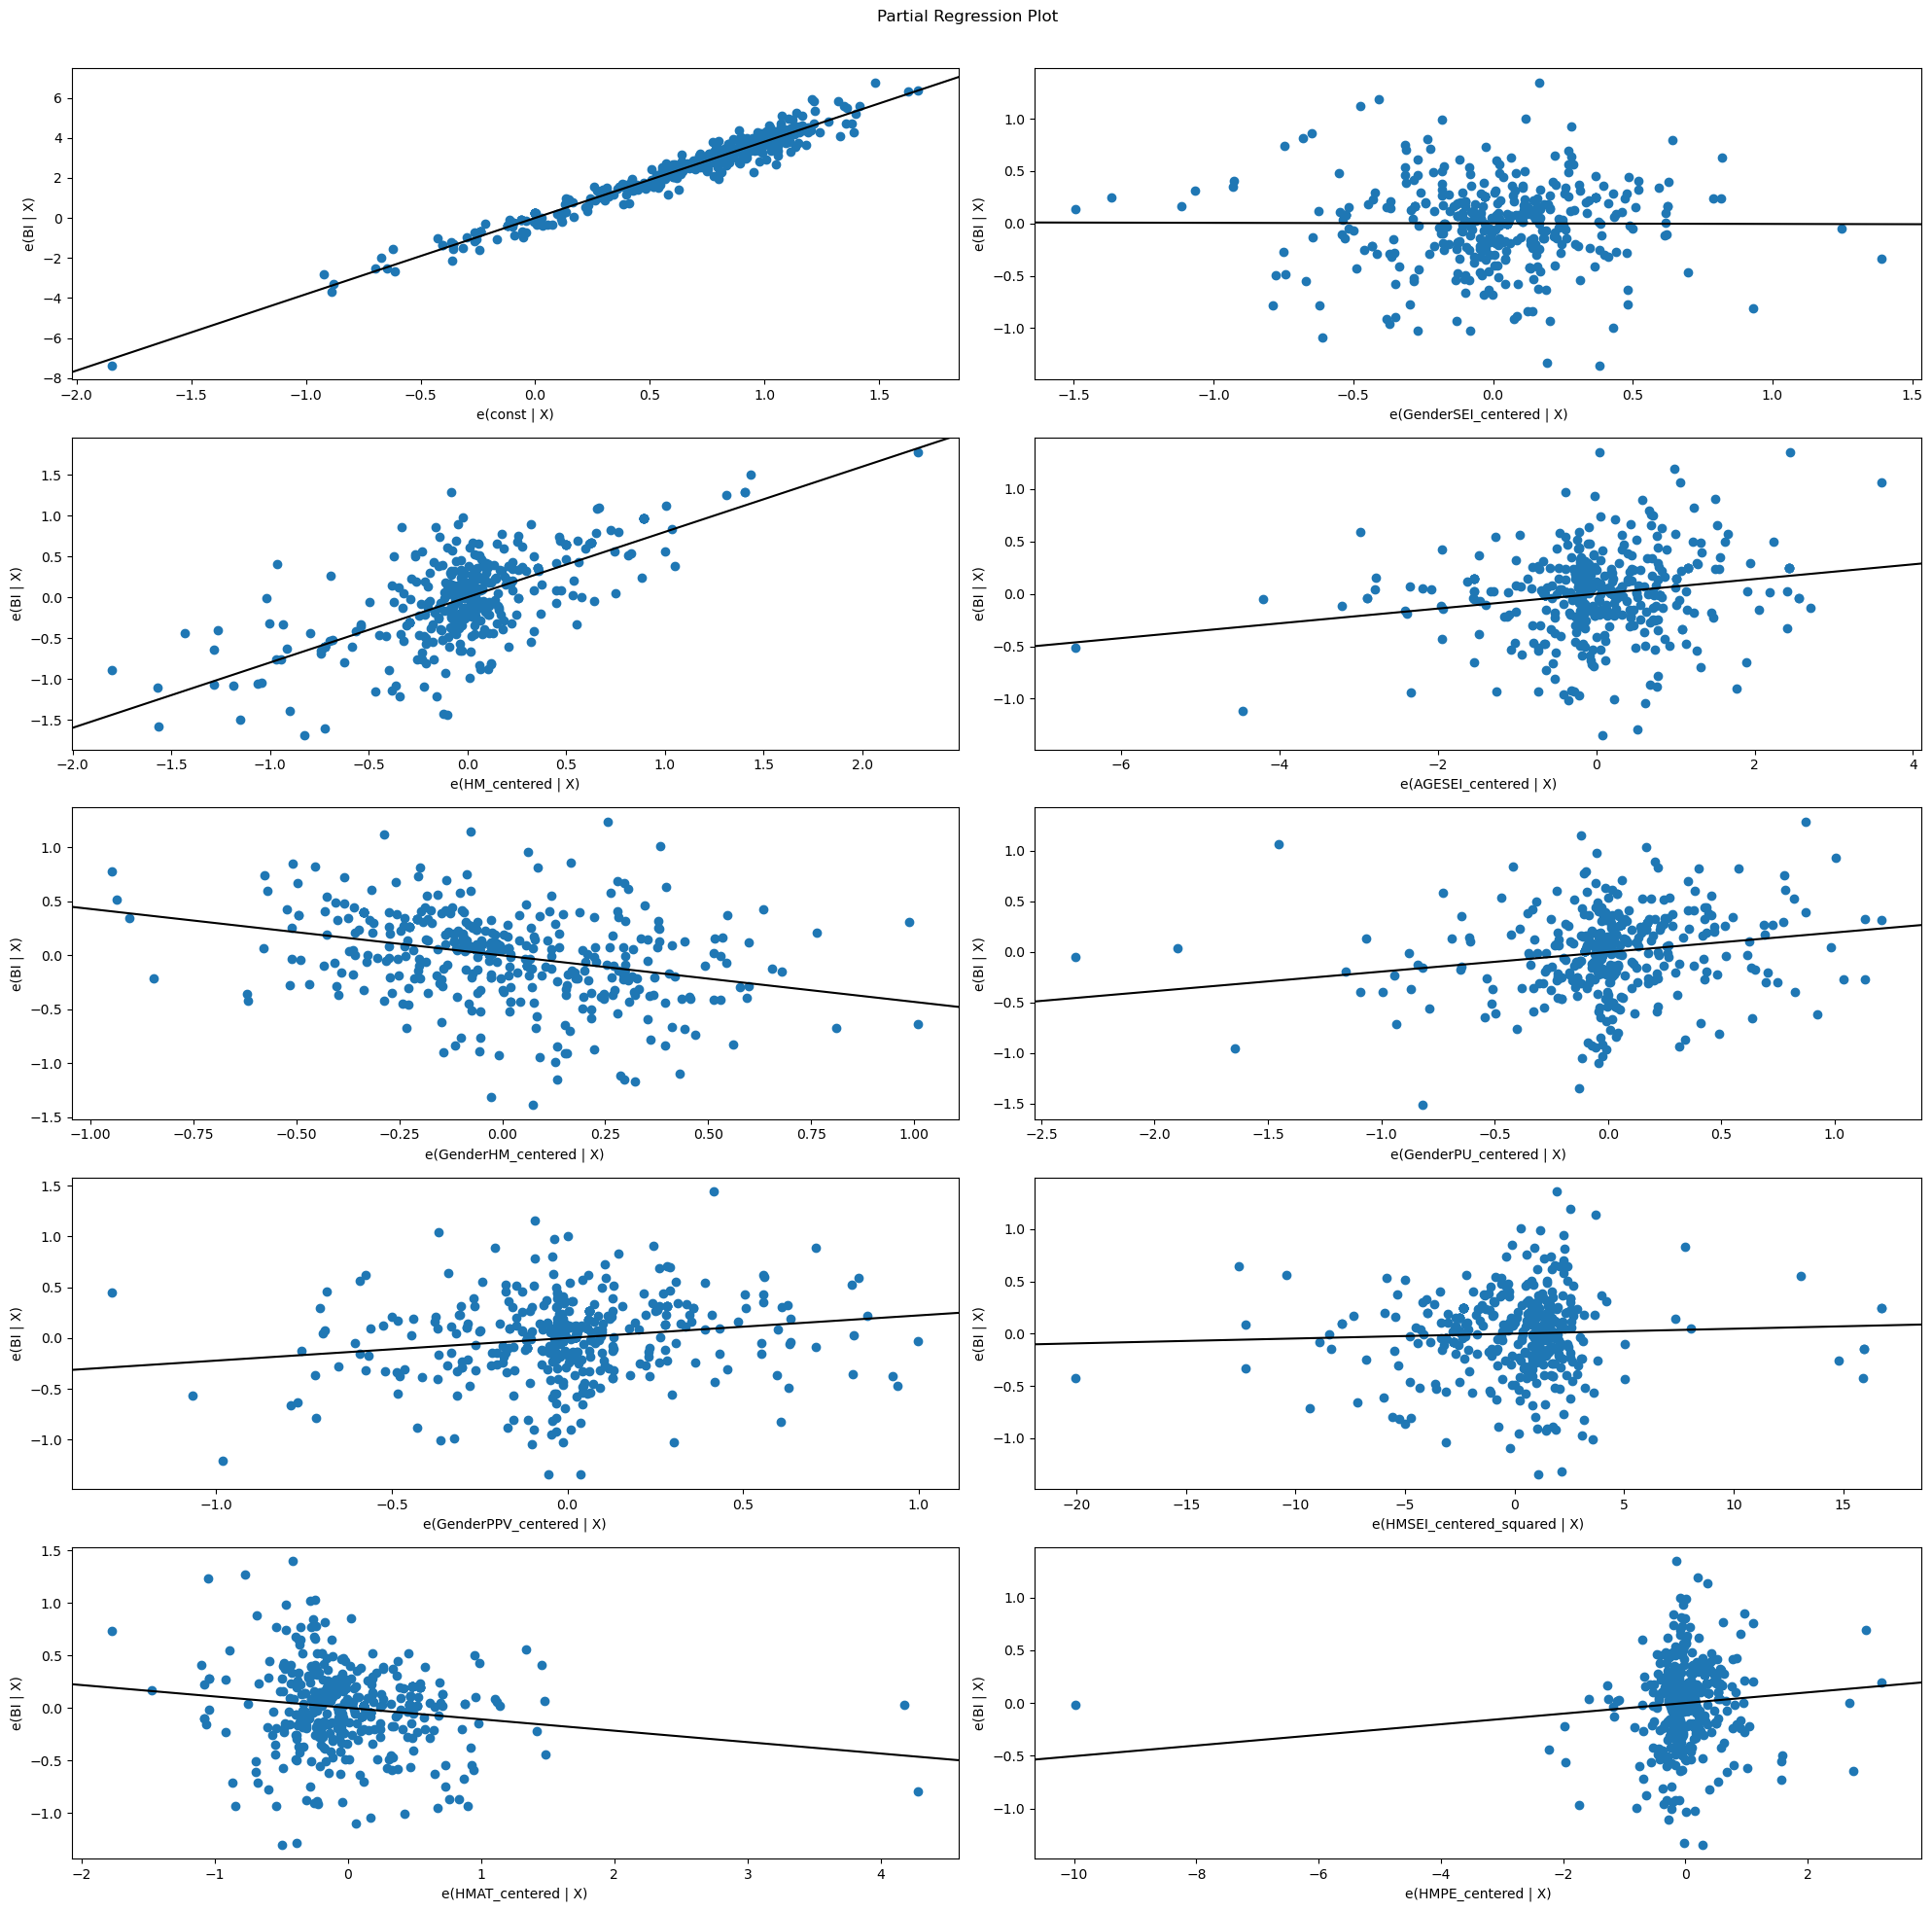

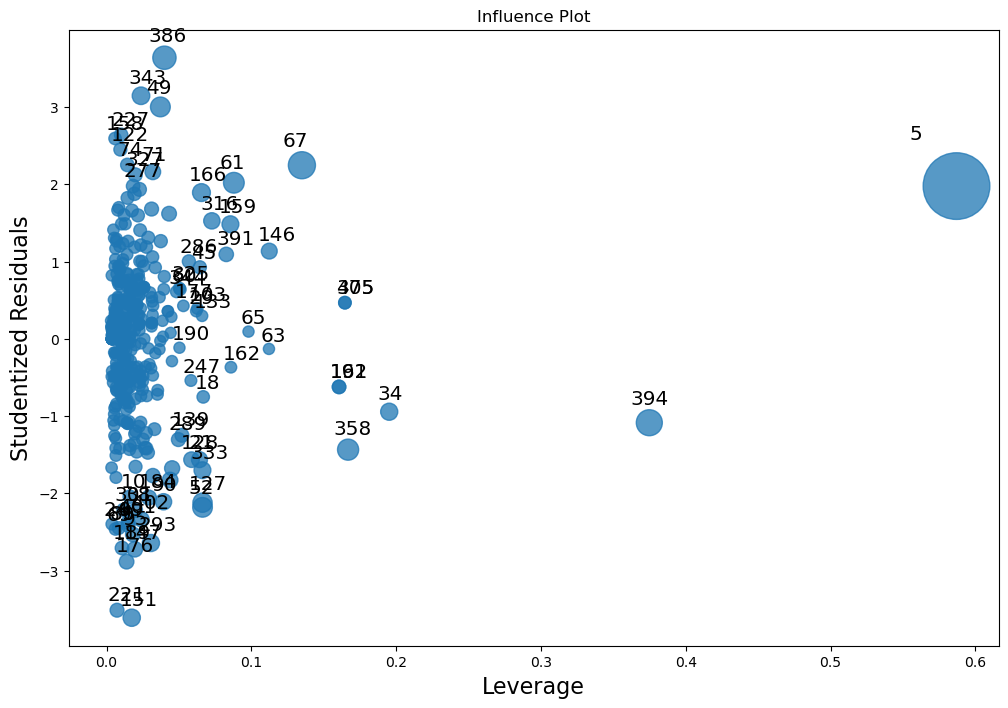

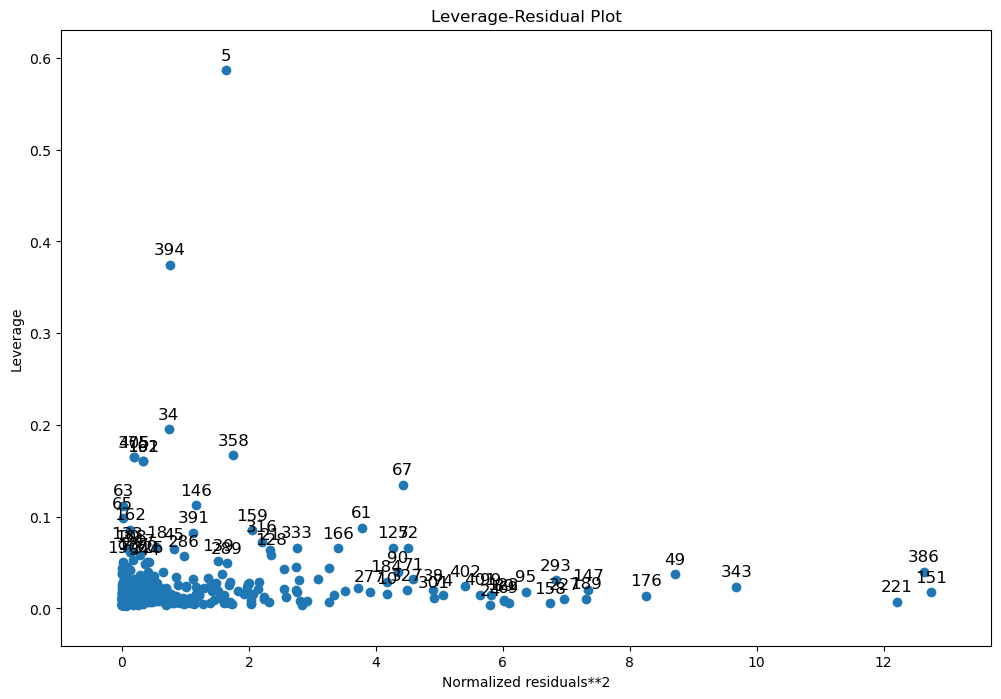

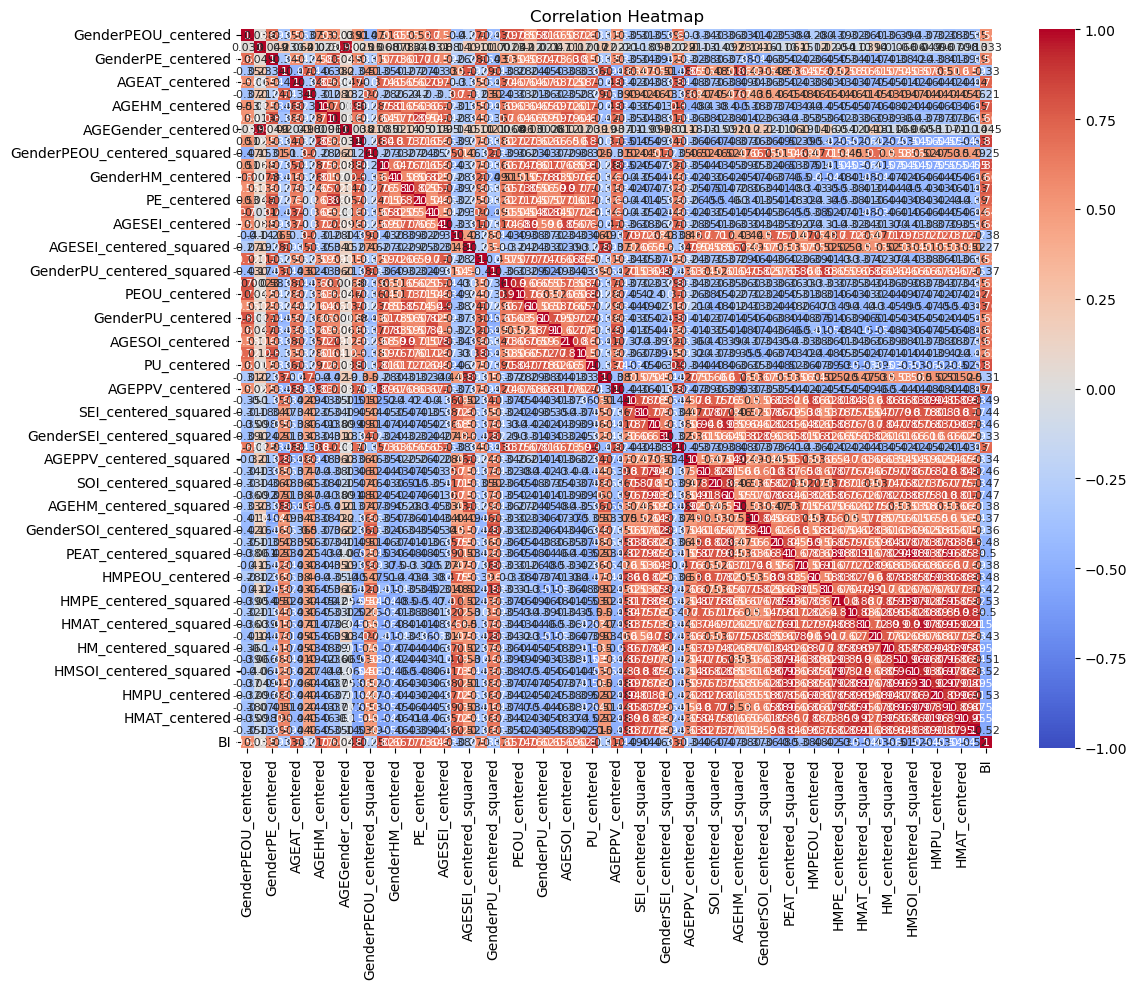

end of script 2


In [15]:
print(' 3. STATS Model with most significant features from model.summary generated in step 2')

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', module='statsmodels')

# Assuming df_survey_cleaned is your dataframe
y = df_survey_cleaned['BI']
X = df_survey_cleaned[['GenderSEI_centered','HM_centered','AGESEI_centered','GenderHM_centered','GenderPU_centered','GenderPPV_centered',
                       'HMSEI_centered_squared','HMAT_centered','HMPE_centered']]

# Add a constant term to the independent variables
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()


#print model summary results
print(model.summary())

import numpy as np
from sklearn.metrics import mean_squared_error, explained_variance_score

# Assuming you have already created your model using statsmodels like this:
# model = sm.OLS(y, X).fit()

# Get the predicted values
y_pred = model.predict(X)

# Calculate MSE
mse = mean_squared_error(y, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate EVS
evs = explained_variance_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Explained Variance Score (EVS): {evs:.4f}")



# 2. Q-Q Plot
fig = sm.qqplot(model.resid, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

# 3. Partial Regression Plots
fig = sm.graphics.plot_partregress_grid(model, fig=plt.figure(figsize=(20, 20)))
plt.show()

# 4. Influence Plot
fig, ax = plt.subplots(figsize=(12, 8))
sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
plt.title("Influence Plot")
plt.show()

# 5. Leverage-Residual Plot
fig, ax = plt.subplots(figsize=(12, 8))
sm.graphics.plot_leverage_resid2(model, ax=ax)
plt.title("Leverage-Residual Plot")
plt.show()


# 7. Correlation Heatmap
# 7. Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_survey_cleaned[feature_vars + ['BI']].corr(), 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            center=0,
            annot_kws={'size': 8})  # Adjust this value to change font size
plt.title("Correlation Heatmap")
plt.tight_layout()  # This ensures the entire plot fits within the figure
plt.show()
print('end of script 2')

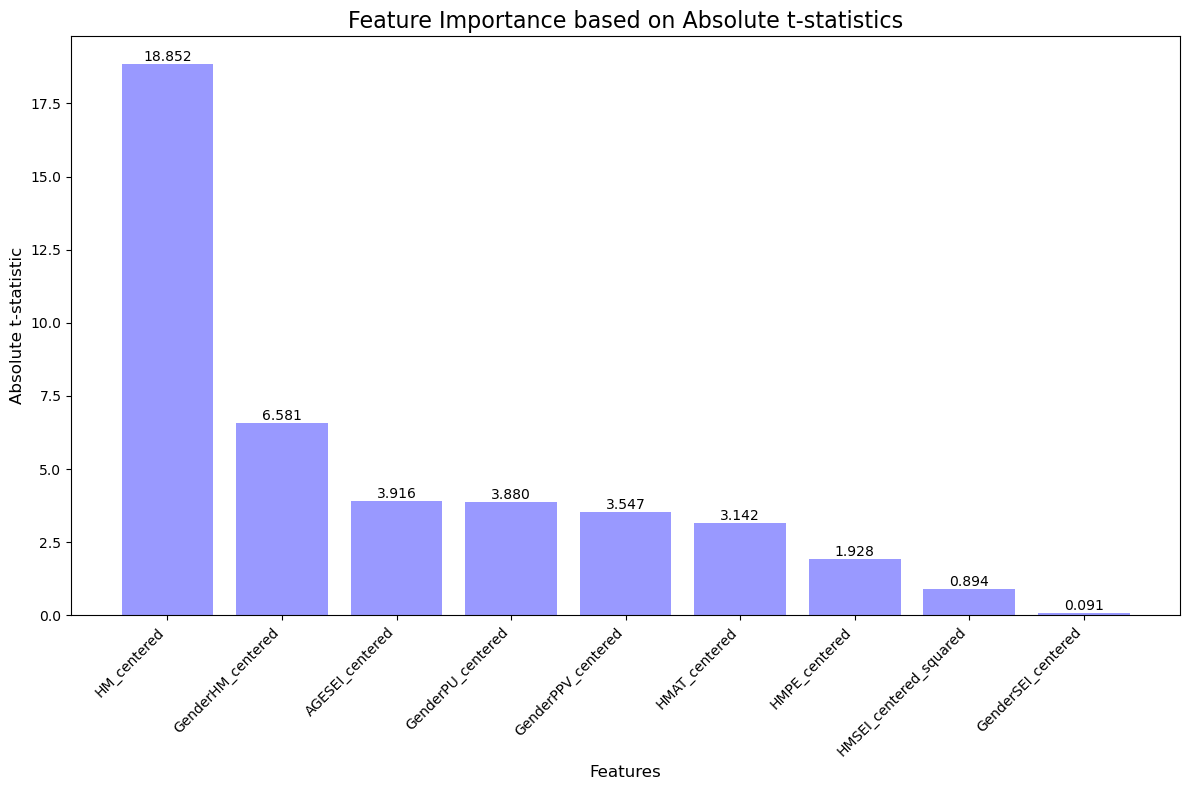

OLS Feature Importance plot has been saved.


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming you have your OLS model in a variable called 'model'

# Get feature importances (using absolute t-statistics)
feature_importance = np.abs(model.tvalues[1:])  # Exclude the constant term

# Get feature names
feature_vars = model.model.exog_names[1:]  # Exclude the constant term

# Create a dictionary of feature importances
importance_dict = dict(zip(feature_vars, feature_importance))

# Sort features by importance
sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Separate the feature names and importance scores
feature_names, importance_scores = zip(*sorted_features)

# Create the plot
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(feature_names)), importance_scores, align='center', color='blue', alpha=0.4)

# Customize the plot
plt.title('Feature Importance based on Absolute t-statistics', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Absolute t-statistic', fontsize=12)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(importance_scores):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig('OLS_feature_importance.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Close the plot to free up memory
plt.close()

print("OLS Feature Importance plot has been saved.")

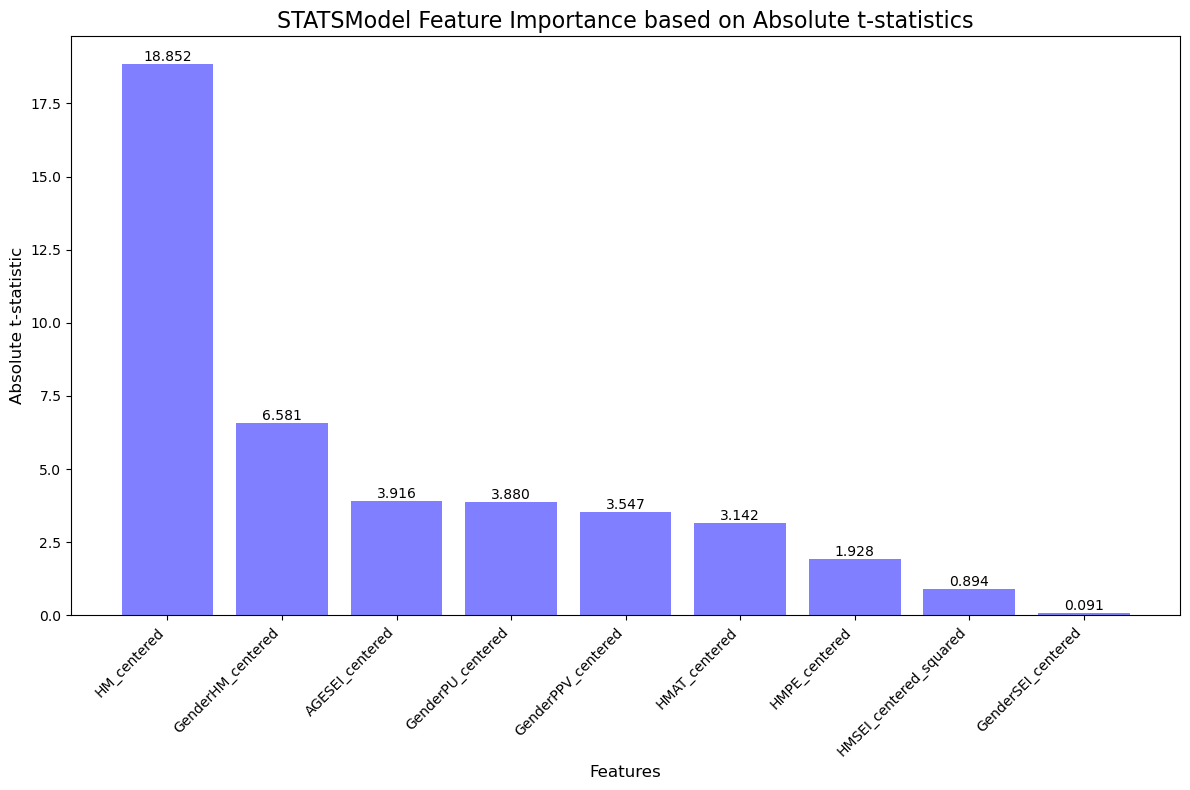

OLS Feature Importance plot has been saved.


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming you have your OLS model in a variable called 'model'

# Get feature importances (using absolute t-statistics)
feature_importance = np.abs(model.tvalues[1:])  # Exclude the constant term

# Get feature names
feature_vars = model.model.exog_names[1:]  # Exclude the constant term

# Create a dictionary of feature importances
importance_dict = dict(zip(feature_vars, feature_importance))

# Sort features by importance
sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Separate the feature names and importance scores
feature_names, importance_scores = zip(*sorted_features)

# Create the plot
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(feature_names)), importance_scores, align='center', color='blue', alpha=0.5)

# Customize the plot
plt.title('STATSModel Feature Importance based on Absolute t-statistics', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Absolute t-statistic', fontsize=12)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(importance_scores):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig('OLS_feature_importance.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Close the plot to free up memory
plt.close()

print("OLS Feature Importance plot has been saved.")

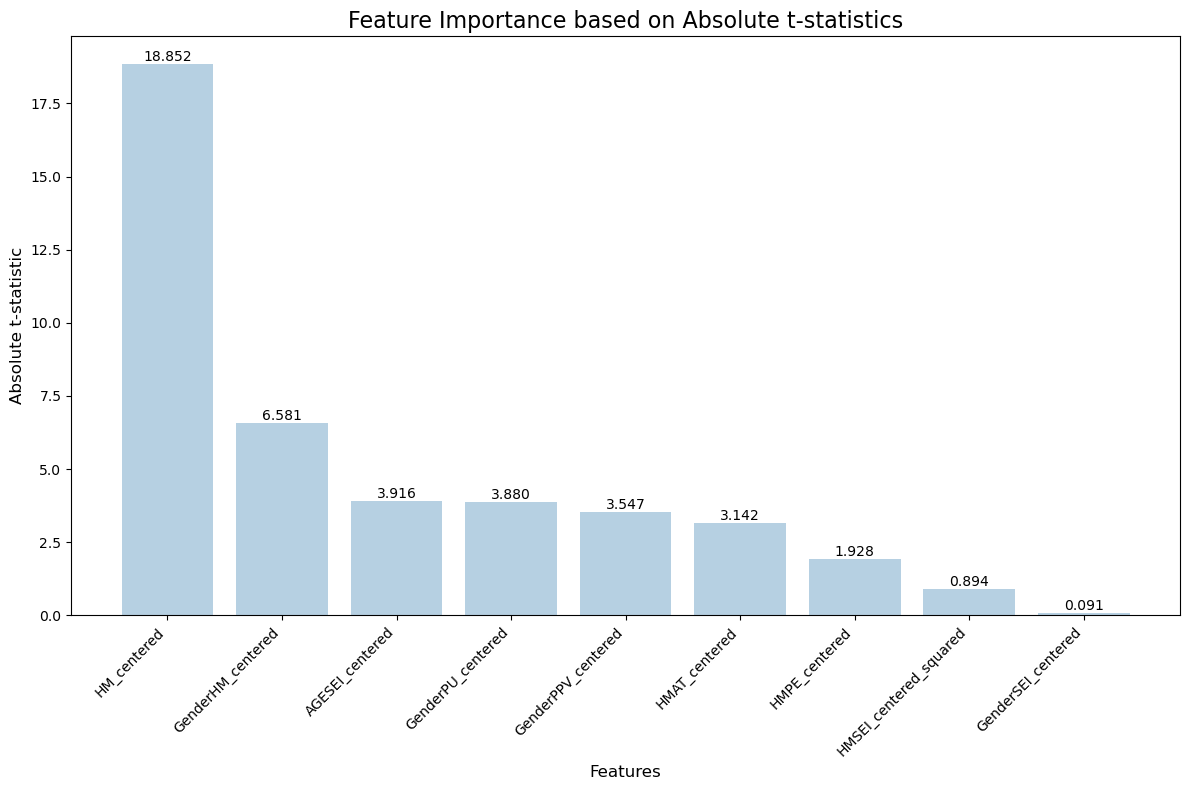

OLS Feature Importance plot has been saved.


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have your OLS model in a variable called 'model'

# Get feature importances (using absolute t-statistics)
feature_importance = np.abs(model.tvalues[1:])  # Exclude the constant term

# Get feature names
feature_vars = model.model.exog_names[1:]  # Exclude the constant term

# Create a dictionary of feature importances
importance_dict = dict(zip(feature_vars, feature_importance))

# Sort features by importance
sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Separate the feature names and importance scores
feature_names, importance_scores = zip(*sorted_features)

# Create the plot with a lighter shade of blue (Powder Blue)
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(feature_names)), importance_scores, align='center', color='#B6D0E2')  # Powder Blue

# Customize the plot
plt.title('Feature Importance based on Absolute t-statistics', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Absolute t-statistic', fontsize=12)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(importance_scores):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig('OLS_feature_importance.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Close the plot to free up memory
plt.close()

print("OLS Feature Importance plot has been saved.")

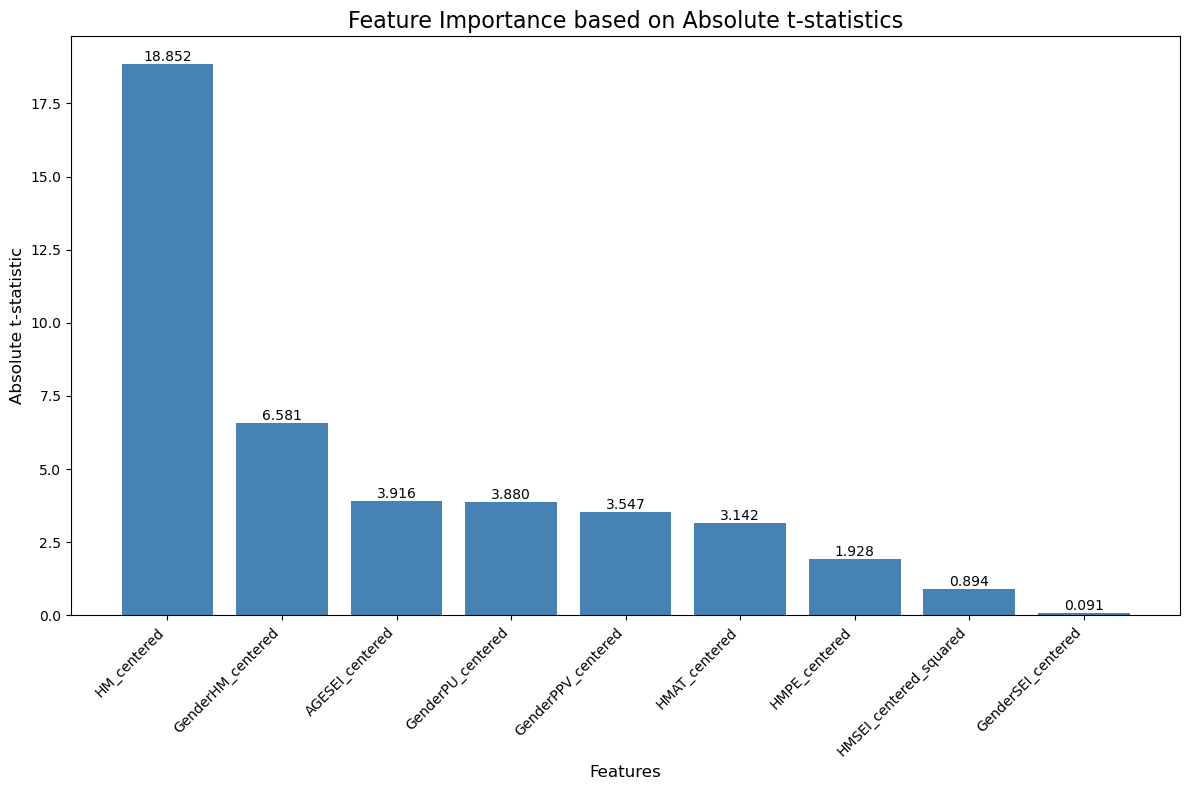

OLS Feature Importance plot has been saved.


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have your OLS model in a variable called 'model'

# Get feature importances (using absolute t-statistics)
feature_importance = np.abs(model.tvalues[1:])  # Exclude the constant term

# Get feature names
feature_vars = model.model.exog_names[1:]  # Exclude the constant term

# Create a dictionary of feature importances
importance_dict = dict(zip(feature_vars, feature_importance))

# Sort features by importance
sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Separate the feature names and importance scores
feature_names, importance_scores = zip(*sorted_features)

# Create the plot with a lighter shade of blue (Powder Blue)
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(feature_names)), importance_scores, align='center', color='#4682B4')  # Powder Blue

# Customize the plot
plt.title('Feature Importance based on Absolute t-statistics', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Absolute t-statistic', fontsize=12)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(importance_scores):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig('OLS_feature_importance.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Close the plot to free up memory
plt.close()

print("OLS Feature Importance plot has been saved.")